# Insurance Claims - Data Processing and Modelling 

#### Saving LDA _Smotetomek for Streamlit

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from imblearn.combine import SMOTETomek
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report
import joblib
from sklearn.impute import SimpleImputer

# Load the dataset with parsed dates and set index
df = pd.read_csv("insurance_claims.csv", parse_dates=["policy_bind_date", "incident_date"], index_col="policy_number")

# Check for duplicates
print('Duplicated: ', df.duplicated().sum())
print('\n')

# Ensure consistency on column names
rename = {'capital-gains': 'capital_gains', 'capital-loss': 'capital_loss'}
df.rename(columns=rename, inplace=True)

# Rename '?' strings to specific 'Unknown' or 'No Collision' values
df["collision_type"] = df["collision_type"].apply(lambda x: "No Collision" if str(x) == "?" else x)
df["police_report_available"] = df["police_report_available"].apply(lambda x: "Unknown" if str(x) == "?" else x)
df["property_damage"] = df["property_damage"].apply(lambda x: "Unknown" if str(x) == "?" else x)

# Drop specified columns
col_drop = ['months_as_customer', 'umbrella_limit', 'total_claim_amount', '_c39', 'age', 'policy_bind_date',
            'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'insured_zip',
            'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_relationship',
            'capital_gains', 'capital_loss', 'incident_date', 'incident_city', 'incident_location',
            'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
            'police_report_available', 'injury_claim', 'property_claim', 'auto_make', 'auto_model',
            'auto_year']
df.drop(col_drop, axis=1, inplace=True, errors='ignore')

# Check remaining features and missing values
print('Remaining features: ', df.columns)
print('\n')
print('Missing values: ', df.isna().sum().sum(), 'in the variable authorities_contacted, they will be replaced after the train/test split with the most_frequent value using the SimpleImputer.')
print('\n')
print(df.info())
print('\n')
print(df.head())
print('\n')

# Label Encode the target variable
LabelEnc = LabelEncoder()
df['fraud_reported'] = LabelEnc.fit_transform(df['fraud_reported'])
# labels: 0 = No Fraud, 1 = Fraud

# X / y split
X = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train Set: ', X_train.shape)
print('Test Set: ', X_test.shape)

# Missing values treatment with SIMPLE IMPUTER
# Define numerical and categorical columns
categorical_columns = ['authorities_contacted']
# Instantiate imputer
categorical_imputer = SimpleImputer(strategy='most_frequent')
# Apply to categorical columns
X_train[categorical_columns] = categorical_imputer.fit_transform(X_train[categorical_columns])
X_test[categorical_columns] = categorical_imputer.transform(X_test[categorical_columns])

# **ADD THIS LINE TO SAVE THE CATEGORICAL IMPUTER:**
joblib.dump(categorical_imputer, 'categorical_imputer.joblib')

# Nominal-categorical variables: One-Hot Encoding
# Resetting the index
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# Select columns for encoding
columns_to_encode = ['insured_hobbies', 'incident_type', 'collision_type', 'authorities_contacted', 'incident_state', 'incident_severity', 'property_damage']
# Fit the encoder on the training set
encoder.fit(X_train[columns_to_encode])
# Encode the nominal vars columns for both datasets
X_train_encoded = encoder.transform(X_train[columns_to_encode])
X_test_encoded = encoder.transform(X_test[columns_to_encode])

# Convert the encoded arrays to DataFrames
train_encoded_df = pd.DataFrame(X_train_encoded, index=X_train.index, columns=encoder.get_feature_names_out(columns_to_encode))
test_encoded_df = pd.DataFrame(X_test_encoded, index=X_test.index, columns=encoder.get_feature_names_out(columns_to_encode))

# Drop the original nominal vars column and concatenate the new encoded columns
X_train = pd.concat([X_train.drop(columns=columns_to_encode), train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=columns_to_encode), test_encoded_df], axis=1)

print('Train Set after OHE: ', X_train.shape)
print('Test Set after OHE: ', X_test.shape)

# Scaling (normalization) of numerical variables
minmax_scaler = MinMaxScaler()
minmax_col = ['vehicle_claim']
for column in minmax_col:
    X_train[column] = minmax_scaler.fit_transform(X_train[[column]])
    X_test[column] = minmax_scaler.transform(X_test[[column]])

print('\nTrain Set after Scaling:')
print(X_train.head())
print('\n')

# Apply SMOTETomek for oversampling and undersampling
smotetom = SMOTETomek(random_state=42)
X_train_smotetom, y_train_smotetom = smotetom.fit_resample(X_train, y_train)
# Check the number of samples in each class
print("Original dataset shape:", y_train.value_counts())
print("SMOTETomek dataset shape:", y_train_smotetom.value_counts())
print('\n')

# Train the LDA model
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_smotetom, y_train_smotetom)

# Make predictions on the test set
y_pred = lda_model.predict(X_test)
# Evaluate the model and print the classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

# Save the *fitted* encoder, scaler, and LDA model
joblib.dump(encoder, 'onehot_encoder.joblib')
joblib.dump(minmax_scaler, 'scaler.joblib')
joblib.dump(lda_model, 'lda_model.pkl')

print("\nOneHotEncoder, MinMaxScaler, and LDA model have been saved.")

Duplicated:  0


Remaining features:  Index(['insured_hobbies', 'incident_type', 'collision_type',
       'incident_severity', 'authorities_contacted', 'incident_state',
       'property_damage', 'vehicle_claim', 'fraud_reported'],
      dtype='object')


Missing values:  91 in the variable authorities_contacted, they will be replaced after the train/test split with the most_frequent value using the SimpleImputer.


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 521585 to 556080
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   insured_hobbies        1000 non-null   object
 1   incident_type          1000 non-null   object
 2   collision_type         1000 non-null   object
 3   incident_severity      1000 non-null   object
 4   authorities_contacted  909 non-null    object
 5   incident_state         1000 non-null   object
 6   property_damage        1000 non-null   object
 7   vehicle_

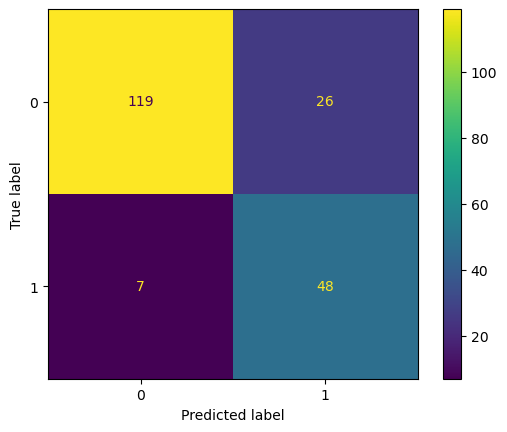

In [41]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lda_model.classes_)
disp.plot()
plt.show()

### Following steps for Streamlit

Saved:
- onehot_encoder.joblib
- scaler.joblib
- lda_model.pkl 